In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

In [3]:
df = pd.read_csv(r"C:\Ki_4\Domain Banking\Financial Transactions\Big_Query_Fetched.csv")
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,errors,target,current_age,gender,yearly_income,total_debt,credit_score,card_brand,card_type,mcc_description
0,16029274,2015-05-01 14:58:00,1492,4818,364.79,Online Transaction,60152,ONLINE,Online/International,Online/International,...,No Error,1,63,Female,56635,13015,786,Visa,Credit,Steelworks
1,16402126,2015-07-20 10:00:00,1542,2906,183.56,Online Transaction,5594,ONLINE,Online/International,Online/International,...,No Error,1,46,Female,55565,34039,731,Mastercard,Debit (Prepaid),Steel Products Manufacturing
2,17222818,2016-01-11 17:26:00,277,4264,25.44,Online Transaction,30497,ONLINE,Online/International,Online/International,...,No Error,1,46,Male,31739,81905,799,Mastercard,Debit,Coated and Laminated Products
3,8465827,2010-09-03 07:06:00,1699,2204,614.71,Online Transaction,47203,ONLINE,Online/International,Online/International,...,No Error,1,67,Female,52929,37514,737,Visa,Debit,Steel Drums and Barrels
4,20952333,2018-03-15 17:47:00,517,106,466.13,Chip Transaction,47203,Rome,Italy,Online/International,...,No Error,1,33,Male,24009,19085,811,Mastercard,Credit,Steel Drums and Barrels


In [4]:
df.isnull().sum()

id                 0
date               0
client_id          0
card_id            0
amount             0
use_chip           0
merchant_id        0
merchant_city      0
merchant_state     0
zip                0
mcc                0
errors             0
target             0
current_age        0
gender             0
yearly_income      0
total_debt         0
credit_score       0
card_brand         0
card_type          0
mcc_description    0
dtype: int64

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113332 entries, 0 to 113331
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               113332 non-null  int64  
 1   date             113332 non-null  object 
 2   client_id        113332 non-null  int64  
 3   card_id          113332 non-null  int64  
 4   amount           113332 non-null  float64
 5   use_chip         113332 non-null  object 
 6   merchant_id      113332 non-null  int64  
 7   merchant_city    113332 non-null  object 
 8   merchant_state   113332 non-null  object 
 9   zip              113332 non-null  object 
 10  mcc              113332 non-null  int64  
 11  errors           113332 non-null  object 
 12  target           113332 non-null  int64  
 13  current_age      113332 non-null  int64  
 14  gender           113332 non-null  object 
 15  yearly_income    113332 non-null  int64  
 16  total_debt       113332 non-null  int6

,id,client_id,card_id,amount,merchant_id,mcc,target,current_age,yearly_income,total_debt,credit_score
count,1.133320e+05,113332.000000,113332.000000,113332.000000,113332.000000,113332.000000,113332.000000,113332.000000,113332.000000,113332.00000,113332.000000
mean,1.558125e+07,1027.572698,3461.945329,51.011845,48304.939267,5527.908296,0.117637,54.257447,46355.373469,57378.98425,713.867443
std,4.728226e+06,583.067527,1677.266698,108.265102,25937.102862,896.621075,0.322179,15.733996,24412.788261,51937.54451,65.598973
min,7.475491e+06,0.000000,0.000000,-500.000000,19.000000,1711.000000,0.000000,23.000000,1.000000,0.00000,488.000000
25%,1.147448e+07,520.000000,2408.000000,9.480000,26810.000000,5300.000000,0.000000,43.000000,32576.000000,16040.00000,684.000000
50%,1.571448e+07,1072.000000,3571.000000,31.850000,47203.000000,5499.000000,0.000000,52.000000,40867.000000,51428.00000,716.000000
75%,1.961812e+07,1534.000000,4866.000000,71.000000,69431.000000,5812.000000,0.000000,64.000000,53702.000000,84507.00000,756.000000
max,2.376166e+07,1998.000000,6138.000000,4978.450000,100340.000000,9402.000000,1.000000,101.000000,280199.000000,461854.00000,850.000000


In [10]:
def focal_loss_obj(y_true, y_pred):
    gamma = 2.0
    alpha = 0.75 # Tăng alpha lên để ưu tiên lớp 1 (Fraud)
    
    preds = 1.0 / (1.0 + np.exp(-y_pred))
    
    # Gradient và Hessian cho Focal Loss
    grad = (preds - y_true) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - preds)**gamma * y_true + preds**gamma * (1 - y_true)))
    hess = preds * (1 - preds) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - preds)**gamma * y_true + preds**gamma * (1 - y_true)))
    return grad, hess

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

# 1. Định nghĩa hàm Focal Loss
# alpha: kiểm soát trọng số giữa 0 và 1 (thường chọn 0.25)
# gamma: kiểm soát việc tập trung vào các mẫu "khó" (thường chọn 2.0)
def focal_loss_obj(y_true, y_pred):
    gamma = 2.0
    alpha = 0.25
    
    # y_pred đầu vào của custom objective là logit (chưa qua sigmoid)
    preds = 1.0 / (1.0 + np.exp(-y_pred)) # Chuyển sang xác suất (sigmoid)
    
    # Tính Gradient
    grad = (preds - y_true) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - preds)**gamma * y_true + preds**gamma * (1 - y_true)))
    
    # Tính Hessian (Đạo hàm bậc 2)
    # Để đơn giản và ổn định, ta sử dụng xấp xỉ Hessian
    hess = preds * (1 - preds) * ((alpha * y_true + (1 - alpha) * (1 - y_true)) * ((1 - preds)**gamma * y_true + preds**gamma * (1 - y_true)))
    
    return grad, hess

# --- PHẦN TIỀN XỬ LÝ DỮ LIỆU CỦA BẠN ---
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df = df.sort_values('date').reset_index(drop=True)

col_drop = [
    'id', 'date', 'client_id', 'card_id', 'merchant_id',
    'merchant_city', 'mcc_description', 'errors', 'zip' 
]
X = df.drop(columns=col_drop + ['target'])
y = df['target']

# --- TIME SERIES SPLIT ---
tscv = TimeSeriesSplit(n_splits=5)
fold = 1

for train_index, test_index in tscv.split(X):
    print(f"\n--- Đang huấn luyện Fold {fold} (Focal Loss) ---")
    
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Label Encoding (Xử lý kỹ để tránh leakage)
    cat_cols = X_train.select_dtypes(include=['object']).columns
    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_test[col] = X_test[col].apply(lambda x: le_dict.get(str(x), -1))

    # --- KHỞI TẠO XGBOOST VỚI CUSTOM OBJECTIVE ---
    # Lưu ý: Khi dùng custom objective, scale_pos_weight sẽ KHÔNG có tác dụng 
    # vì Focal Loss đã tự xử lý trọng số lớp bên trong hàm rồi.
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective=focal_loss_obj, # Sử dụng hàm tự định nghĩa
        random_state=42,
        tree_method='hist' # Dùng hist để chạy nhanh hơn với dữ liệu 100k dòng
    )

    # Huấn luyện
    model.fit(X_train, y_train)

    # Khi dùng custom objective, model.predict trả về logit hoặc xác suất tùy version
    # Để an toàn, chúng ta lấy xác suất qua sigmoid nếu cần
    y_prob_raw = model.predict(X_test, output_margin=True)
    y_prob = 1.0 / (1.0 + np.exp(-y_prob_raw)) # Sigmoid tay để chắc chắn
    y_pred = (y_prob > 0.5).astype(int)

    # Đánh giá
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC cho Fold {fold}: {auc:.4f}")
    
    fold += 1

print("\nKết quả chi tiết của Fold cuối cùng (Focal Loss):")
print(classification_report(y_test, y_pred))


--- Đang huấn luyện Fold 1 (Focal Loss) ---
ROC-AUC cho Fold 1: 0.7650

--- Đang huấn luyện Fold 2 (Focal Loss) ---
ROC-AUC cho Fold 2: 0.8971

--- Đang huấn luyện Fold 3 (Focal Loss) ---
ROC-AUC cho Fold 3: 0.9157

--- Đang huấn luyện Fold 4 (Focal Loss) ---
ROC-AUC cho Fold 4: 0.8063

--- Đang huấn luyện Fold 5 (Focal Loss) ---
ROC-AUC cho Fold 5: 0.6776

Kết quả chi tiết của Fold cuối cùng (Focal Loss):
              precision    recall  f1-score   support

           0       0.87      0.99      0.92     16329
           1       0.32      0.02      0.05      2559

    accuracy                           0.86     18888
   macro avg       0.59      0.51      0.49     18888
weighted avg       0.79      0.86      0.81     18888



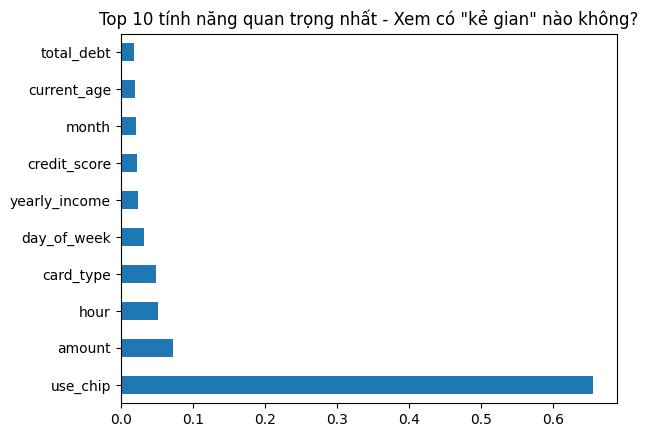

In [9]:
# Kiểm tra xem cột nào đang đóng góp "quá mức" vào kết quả
import matplotlib.pyplot as plt

feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 tính năng quan trọng nhất - Xem có "kẻ gian" nào không?')
plt.show()